# Path Generation code (4.1.1)



In [1]:
# Code development statement:

# Generative AI tools were used for assistance,

# code refinement and improving comments.

# All algorithms were independently reviewed, tested, and modified

# by the author to ensure correctness and understanding.

import random

from image_processing import (
    find_colour_marker,
    detect_corner_markers,
    load_and_process_image,
    split_into_cells,
    detect_maze_walls,
    synchronise_walls,
    display_occupancy_map
)

from graph import (
    create_grid_graph,
    add_valid_edges,
    print_maze,
    print_maze_with_path
)

from path_finder import (
    command_optimal_path,
    path_to_commands
)

random.seed(42)

In [2]:
seed = 42
image_file = "./maze_images/img_obst_3.jpg"

# Task 1 - Occupancy map
unsafe_kernel_size = 7
unsafe_iterations = 3

# Task 3 - BFS
bfs_n = 9
bfs_start_node = 10
bfs_end_node = 6

# # Task 4 - PRM and Dijkstra
# prm_total_nodes_count = 30
# prm_connection_radius = 200
# prm_start_location = (50, 50)
# prm_goal_location = (450, 450)

# # Task 5 - RRT
# rrt_max_nodes_count = 500
# rrt_step_size = 40
# rrt_max_connection_length = 200
# rrt_start_location = (50, 50)
# rrt_goal_location = (450, 450)



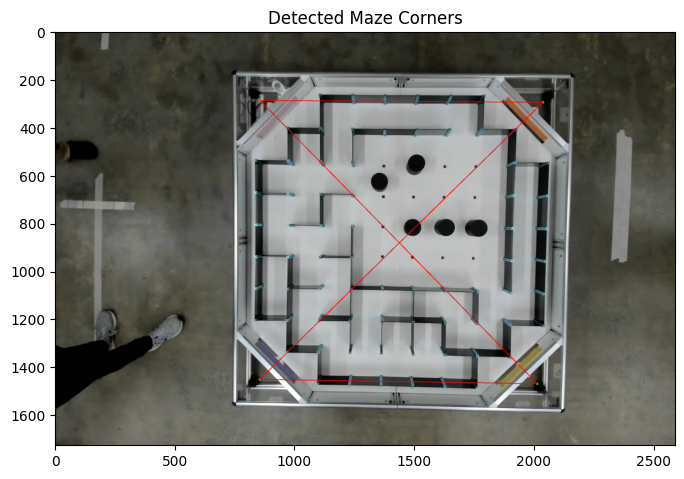

Image size: 900 x 900
Cell size: 100 x 100


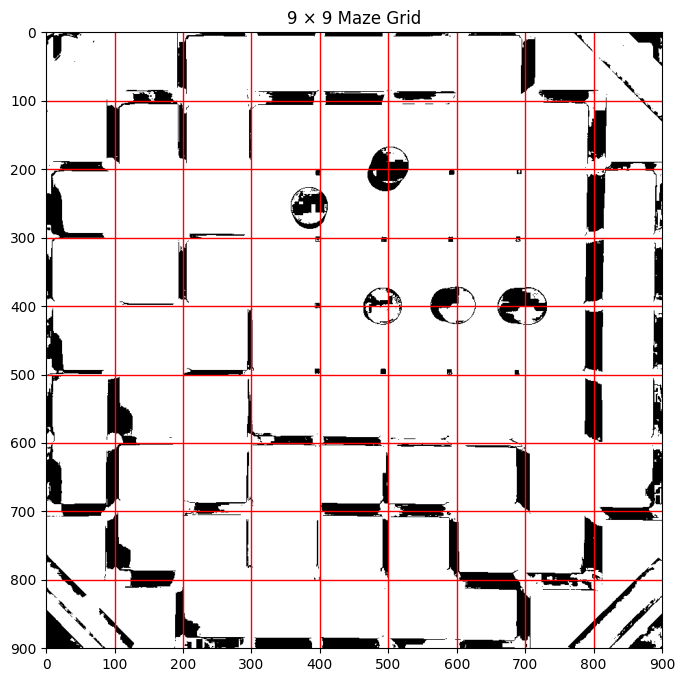


Digital maze with path:
+---+---+---+---+---+---+---+---+---+
        |                 G |        
+   +---+   +---+---+---+   +---+   +
    | S |   |             •     |    
+---+   +   +   +   +   +   +   +---+
|     •   •   •   •   •   •     |   |
+---+   +---+   +   +   +   +   +   +
|       |                       |   |
+   +---+   +   +   +   +   +   +   +
|           |                   |   |
+---+   +---+   +   +   +   +   +   +
|   |       |                   |   |
+   +---+   +---+---+---+---+   +   +
|   |       |       |       |       |
+---+   +---+   +---+---+   +   +---+
    |       |   |   |   |       |    
+   +---+   +   +   +   +---+---+   +
|       |                   |        
+---+   +---+---+---+---+---+   +   +

Path: [10, 19, 20, 21, 22, 23, 24, 15, 6]
Number of moves: 8

Commands:
['r', 'r', 'f', 'l', 'f', 'f', 'f', 'f', 'f', 'l', 'f', 'f']

Command string:
rrflffffflff


In [3]:
def main():

    # ---------------------------------------------------------

    # 1. Process camera image

    # ---------------------------------------------------------

    binary = load_and_process_image(image_file)
    cells, cell_width, cell_height = split_into_cells(binary, bfs_n)
    print("Image size:", binary.shape[1], "x", binary.shape[0])
    print("Cell size:", cell_width, "x", cell_height)
    display_occupancy_map(binary, cell_width, cell_height, bfs_n)

    # ---------------------------------------------------------

    # 2. Detect maze walls

    # ---------------------------------------------------------

    maze = detect_maze_walls(cells, bfs_n)

    # ---------------------------------------------------------

    # 3. Create graph representation

    # ---------------------------------------------------------

    graph = create_grid_graph(bfs_n)
    synchronise_walls(graph, maze, bfs_n)
    add_valid_edges(graph, bfs_n)

    # print("\nDetected maze:")
    # print_maze(graph, bfs_n, bfs_n)

    # ---------------------------------------------------------

    # 4. Find path using BFS

    # ---------------------------------------------------------
    path, commands = command_optimal_path(graph, bfs_start_node, bfs_end_node, start_direction="N")

    if path is None:
        print("\nNo path found.")
    else:
        # Display the digital maze with the BFS path traced.
        print("\nDigital maze with path:")
        print_maze_with_path(graph, path, bfs_n, bfs_n)
        print("\nPath:", path)
        print("Number of moves:", len(path) - 1)

        # ---------------------------------------------------------

        # 5. Convert path into robot commands

        # ---------------------------------------------------------

        commands = path_to_commands(path, start_direction="N", cols=bfs_n)

        print("\nCommands:")
        print(commands)
        print("\nCommand string:")
        print("".join(commands))

if __name__ == "__main__":
    main()